# Binomial Tree Option Pricing (CRR Model)

This notebook demonstrates the Cox-Ross-Rubinstein (CRR) binomial tree model for pricing European and American options.  
It will compare binomial prices to the Black-Scholes model, analyze convergence, and illustrate early exercise behavior.


## CRR Binomial Model Overview

The Cox-Ross-Rubinstein model constructs a recombining price tree using:

- Up factor: $ u = e^{\sigma \sqrt{\Delta t}} $
- Down factor: $ d = 1/u $
- Risk‑neutral probability: $p = \frac{e^{r \Delta t} - d}{u - d}$



Option values are computed by backward induction:



$
V_n = e^{-r \Delta t} \left( p V_{n+1}^u + (1-p) V_{n+1}^d \right)
$



For American options, early exercise is allowed at each node.


In [ ]:
import sys, os
sys.path.append(os.path.abspath(".."))

import matplotlib.pyplot as plt

from options_pricing.models.black_scholes import BlackScholes
from options_pricing.models.binomial_tree import BinomialTree

In [2]:
# Parameters
S = 100
K = 100
r = 0.05
T = 1.0
sigma = 0.2

## European Call: Binomial vs Black-Scholes

Compute the European call price using both:

- Black-Scholes closed-form solution  
- CRR binomial tree with increasing number of steps  

The binomial price should converge to the Black-Scholes price as the number of steps increases.

In [3]:
bs = BlackScholes(S, K, r, T, sigma)
bs_call = bs.call_price()

steps_list = [5, 10, 25, 50, 100, 200, 500, 1000]
binomial_prices = []

for steps in steps_list:
    tree = BinomialTree(S, K, T, r, sigma, steps)
    price = tree.price("call", "european")
    binomial_prices.append(price)

for steps, price in zip(steps_list, binomial_prices):
    print(f"Steps={steps:4d}  Binomial={price:.6f}  BS={bs_call:.6f}")

Steps=   5  Binomial=10.805934  BS=10.450584
Steps=  10  Binomial=10.253409  BS=10.450584
Steps=  25  Binomial=10.520966  BS=10.450584
Steps=  50  Binomial=10.410692  BS=10.450584
Steps= 100  Binomial=10.430612  BS=10.450584
Steps= 200  Binomial=10.440591  BS=10.450584
Steps= 500  Binomial=10.446585  BS=10.450584
Steps=1000  Binomial=10.448584  BS=10.450584


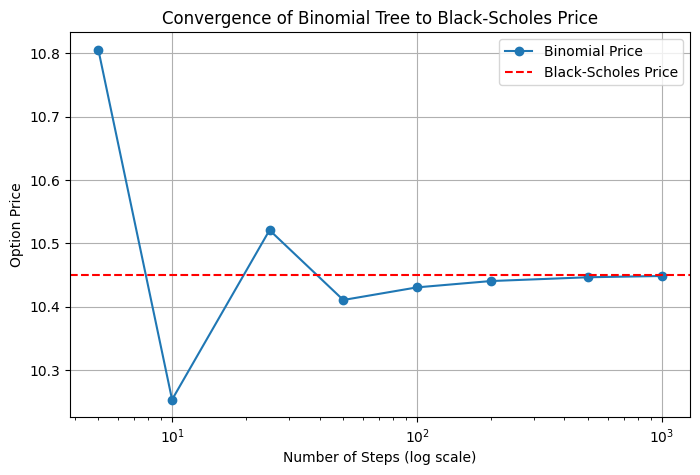

In [4]:
plt.figure(figsize=(8, 5))
plt.plot(steps_list, binomial_prices, marker='o', label="Binomial Price")
plt.axhline(bs_call, color='red', linestyle='--', label="Black-Scholes Price")

plt.xscale("log")
plt.xlabel("Number of Steps (log scale)")
plt.ylabel("Option Price")
plt.title("Convergence of Binomial Tree to Black-Scholes Price")
plt.legend()
plt.grid(True)
plt.show()

## American vs European Call (No Dividends)

For non-dividend-paying stocks, early exercise of a call option is never optimal, therefore:

**American Call = European Call**

This can be verified numerically.


In [5]:
tree_euro = BinomialTree(S, K, T, r, sigma, 500).price("call", "european")
tree_amer = BinomialTree(S, K, T, r, sigma, 500).price("call", "american")

print("European call:", tree_euro)
print("American call:", tree_amer)
print("Difference:", tree_amer - tree_euro)

European call: 10.44658513644654
American call: 10.44658513644654
Difference: 0.0


## American vs European Put

Unlike calls, American puts can be exercised early, thus:

**American Put ≥ European Put**

Both prices can be computed and compared to examine the early exercise premium.


In [6]:
tree_euro_put = BinomialTree(S, K, T, r, sigma, 500).price("put", "european")
tree_amer_put = BinomialTree(S, K, T, r, sigma, 500).price("put", "american")

print("European put:", tree_euro_put)
print("American put:", tree_amer_put)
print("Early exercise premium:", tree_amer_put - tree_euro_put)

European put: 5.5695275865157745
American put: 6.088810110703037
Early exercise premium: 0.5192825241872621
